# Actividad 9. Eficiencia de los algoritmos

**Materia:** Lenguajes de computación

| Integrante | Nombre completo | No. de cuenta |
|---|---|---|
| 1 | Axel Garcia Arellano | [201251] |
| 2 | Angel Rugerio Jimenez | [201720] |

**Objetivo:** implementar el **Ordenamiento por Inserción** y el **Ordenamiento por Mezcla (Merge Sort)**, medir su **tiempo** y **memoria máxima** con distintos conjuntos de datos, y contrastar los resultados con su complejidad teórica: Inserción $O(n^2)$ y Mezcla $O(n \log n)$.

**Estructura del notebook:** identificación → explicación de los algoritmos → implementación → generación de datos → mediciones → tabla → gráficas → conclusión.

## 1. Configuración

- `SEMILLA`: semilla fija para que los conjuntos de datos sean reproducibles.
- `EJECUTAR_INSERCION_1M`: Inserción con $n = 1{,}000{,}000$ hace del orden de $10^{12}$ operaciones; en Python puro tardaría **varias horas por corrida**. Si vale `False`, su tiempo se **estima** a partir de la medición real con $n = 100{,}000$ (factor teórico $\times 100$, porque $(10^6/10^5)^2 = 100$) y su memoria se reporta como **no medida**.
- `MEDIR_MEMORIA_INSERCION_100K`: bajo `tracemalloc`, Inserción se vuelve **decenas de veces más lenta** (ver sección 6). Si vale `False`, el **tiempo** de Inserción con 100,000 se mide normalmente, pero su **memoria** se reporta como **no medida**.
- `ARCHIVO_PARCIAL`: cada medición se guarda en un JSON en cuanto termina; si el notebook se interrumpe, al volver a ejecutarlo se reutilizan las mediciones ya hechas (`REUTILIZAR_PARCIALES = True`).

In [1]:
import gc
import json
import math
import os
import random
import time
import tracemalloc

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEMILLA = 42
TAMANIOS = [1_000, 100_000, 1_000_000]
EJECUTAR_INSERCION_1M = False      # True = medir Inserción con 1,000,000 (varias horas)
MEDIR_MEMORIA_INSERCION_100K = False  # True = medir con tracemalloc la memoria de Inserción con 100,000 (muy lento)
REUTILIZAR_PARCIALES = True        # retomar mediciones guardadas si hubo interrupción
ARCHIVO_PARCIAL = "resultados_parciales.json"

## 1.1 Equipo de pruebas

Los tiempos absolutos dependen del equipo donde se ejecutan; lo comparable entre equipos es la **forma** en que crecen con n. Todas las mediciones de este notebook se tomaron en:

| Característica | Valor |
|---|---|
| Equipo | Laptop MSI Katana GF76 12UD |
| Procesador | Intel Core i7-12700H (12.ª generación), 14 núcleos (6 de rendimiento + 8 de eficiencia), 20 hilos, hasta 4.7 GHz |
| Caché | L1d 544 KiB · L2 11.5 MiB · L3 24 MiB |
| Memoria RAM | 16 GB (15.3 GB utilizables) |
| Almacenamiento | SSD NVMe Micron 2400, 512 GB |
| Sistema operativo | Arch Linux, kernel 7.2.6 (x86_64) |
| Energía | Conectada a corriente, perfil de CPU `powersave` (frecuencia dinámica) |
| Python | CPython 3.12.14 (entorno virtual `uv`) |
| Librerías | pandas 3.0.6 · matplotlib 3.11.2 |

> Los algoritmos corren en **un solo hilo**, así que solo usan un núcleo; el número de núcleos no acelera las mediciones. Como el i7-12700H tiene núcleos de rendimiento y de eficiencia, el sistema operativo puede asignar el proceso a uno u otro tipo de núcleo, lo que puede producir variación entre corridas largas.

La siguiente celda obtiene del sistema los datos principales:

In [ ]:
import os
import platform
import sys

import matplotlib
import pandas

def leer_linea(ruta, prefijo):
    # Lee la primera línea que empieza con `prefijo` de un archivo de /proc (solo Linux)
    try:
        with open(ruta, encoding="utf-8") as f:
            for linea in f:
                if linea.startswith(prefijo):
                    return linea.split(":", 1)[1].strip()
    except OSError:
        pass
    return "no disponible"

ram_kb = leer_linea("/proc/meminfo", "MemTotal")
ram_gb = f"{int(ram_kb.split()[0]) / 1024**2:.1f} GB" if ram_kb != "no disponible" else ram_kb

print(f"Procesador        : {leer_linea('/proc/cpuinfo', 'model name')}")
print(f"Hilos lógicos     : {os.cpu_count()}")
print(f"Memoria RAM       : {ram_gb}")
print(f"Sistema operativo : {platform.system()} {platform.release()} ({platform.machine()})")
print(f"Python            : {sys.version.split()[0]} ({platform.python_implementation()})")
print(f"pandas            : {pandas.__version__}")
print(f"matplotlib        : {matplotlib.__version__}")

Procesador        : 12th Gen Intel(R) Core(TM) i7-12700H
Hilos lógicos     : 20
Memoria RAM       : 15.3 GB
Sistema operativo : Linux 7.2.6-arch2-1 (x86_64)
Python            : 3.12.14 (CPython)
pandas            : 3.0.6
matplotlib        : 3.11.2


## 2. Ordenamiento por Inserción (Insertion Sort)

**Idea:** funciona como ordenar cartas en la mano. La lista se divide en una parte **ya ordenada** (a la izquierda) y una parte **pendiente** (a la derecha). En cada paso:

1. Se toma el primer elemento pendiente (la **llave**).
2. Se recorre la parte ordenada de derecha a izquierda, **desplazando una posición a la derecha** cada elemento mayor que la llave.
3. Cuando se encuentra un elemento menor o igual (o el inicio de la lista), se **inserta** la llave en el hueco.

**Complejidad:**
- Tiempo: peor caso y caso promedio $O(n^2)$ (en promedio cada llave se desplaza sobre la mitad de la parte ordenada, $\approx n^2/4$ desplazamientos); mejor caso $O(n)$ si la lista ya está ordenada.
- Memoria adicional: $O(1)$ — ordena **in-place** (sobre la misma lista), solo usa unas cuantas variables.
- Es **estable**: los elementos iguales conservan su orden relativo (usa `>` y no `>=`).

In [2]:
def insertion_sort(lista):
    # Ordena la lista in-place (sobre la misma lista) y la devuelve.
    for i in range(1, len(lista)):
        llave = lista[i]          # elemento que vamos a insertar en la parte ordenada lista[0..i-1]
        j = i - 1                 # empezamos a comparar con el último elemento de la parte ordenada
        # Desplazamos a la derecha todos los elementos mayores que la llave
        while j >= 0 and lista[j] > llave:
            lista[j + 1] = lista[j]
            j -= 1
        # j + 1 es el hueco donde la llave queda en su posición correcta
        lista[j + 1] = llave
    return lista

## 3. Ordenamiento por Mezcla (Merge Sort)

**Idea:** estrategia **divide y vencerás**.

1. **Dividir:** si la lista tiene 0 o 1 elementos ya está ordenada (caso base). Si no, se parte a la mitad.
2. **Vencer:** se ordena recursivamente cada mitad.
3. **Combinar (mezclar):** se recorren las dos mitades ordenadas con un índice cada una y se va copiando a una lista nueva el menor de los dos elementos actuales; al agotarse una mitad, se copia el resto de la otra.

**Complejidad:**
- Tiempo: $O(n \log n)$ en **todos** los casos — hay $\log_2 n$ niveles de división y en cada nivel la mezcla recorre los $n$ elementos.
- Memoria adicional: $O(n)$ — la mezcla necesita listas auxiliares (las mitades y el resultado), no es in-place.
- Es **estable** (en empate toma primero el elemento de la mitad izquierda, `<=`).

In [3]:
def merge_sort(lista):
    # Caso base: una lista de 0 o 1 elementos ya está ordenada
    if len(lista) <= 1:
        return lista
    # 1. Dividir: partimos la lista a la mitad
    mitad = len(lista) // 2
    # 2. Vencer: ordenamos recursivamente cada mitad
    izquierda = merge_sort(lista[:mitad])
    derecha = merge_sort(lista[mitad:])
    # 3. Combinar: mezclamos las dos mitades ordenadas
    return mezclar(izquierda, derecha)


def mezclar(izquierda, derecha):
    resultado = []
    i = j = 0
    # Mientras ambas mitades tengan elementos, tomamos el menor de los dos actuales
    while i < len(izquierda) and j < len(derecha):
        if izquierda[i] <= derecha[j]:      # <= mantiene la estabilidad
            resultado.append(izquierda[i])
            i += 1
        else:
            resultado.append(derecha[j])
            j += 1
    # Una de las mitades se agotó: copiamos lo que queda de la otra (ya está ordenado)
    resultado.extend(izquierda[i:])
    resultado.extend(derecha[j:])
    return resultado

## 4. Verificación de correctitud

Antes de medir, comprobamos que ambas funciones ordenan correctamente comparando contra `sorted()` en listas pequeñas (vacía, un elemento, ya ordenada, invertida, con repetidos, con negativos y 200 listas aleatorias). `sorted()` se usa **solo aquí**, nunca en las mediciones.

In [4]:
casos = [
    [],
    [7],
    [1, 2, 3, 4, 5],
    [5, 4, 3, 2, 1],
    [3, 1, 3, 2, 1, 3],
    [0, -5, 12, -5, 8, 0],
]
rng = random.Random(0)
casos += [[rng.randint(-50, 50) for _ in range(rng.randint(0, 60))] for _ in range(200)]

for caso in casos:
    esperado = sorted(caso)
    assert insertion_sort(list(caso)) == esperado, f"Inserción falló con {caso}"
    assert merge_sort(list(caso)) == esperado, f"Mezcla falló con {caso}"

print(f"OK: ambos algoritmos ordenan correctamente los {len(casos)} casos de prueba.")

OK: ambos algoritmos ordenan correctamente los 206 casos de prueba.


## 5. Generación de los conjuntos de datos

Para cada $n \in \{1{,}000;\ 100{,}000;\ 1{,}000{,}000\}$ se generan dos conjuntos (6 en total):

- **Sin repetición:** `random.sample(range(1, n+1), n)` → una permutación aleatoria de $1..n$.
- **Con repetición:** `[random.randint(1, n) for _ in range(n)]` → valores en $1..n$ que pueden repetirse.

Se fija la semilla (`random.seed(SEMILLA)`) **antes de generar cada conjunto**, de modo que cada uno es reproducible por sí solo sin importar el orden de generación. Cada algoritmo recibe una **copia** del mismo conjunto, así ambos ordenan exactamente los mismos datos.

In [5]:
conjuntos = {}
for n in TAMANIOS:
    random.seed(SEMILLA)
    conjuntos[(n, "Sin repetición")] = random.sample(range(1, n + 1), n)
    random.seed(SEMILLA)
    conjuntos[(n, "Con repetición")] = [random.randint(1, n) for _ in range(n)]

for (n, cond), datos in conjuntos.items():
    print(f"n = {n:>9,} | {cond:<15} | valores distintos: {len(set(datos)):>9,} | primeros 8: {datos[:8]}")

n =     1,000 | Sin repetición  | valores distintos:     1,000 | primeros 8: [655, 115, 26, 760, 282, 251, 229, 143]
n =     1,000 | Con repetición  | valores distintos:       637 | primeros 8: [655, 115, 26, 760, 282, 251, 229, 143]
n =   100,000 | Sin repetición  | valores distintos:   100,000 | primeros 8: [83811, 14593, 3279, 97197, 36049, 32099, 29257, 18290]
n =   100,000 | Con repetición  | valores distintos:    63,054 | primeros 8: [83811, 14593, 3279, 97197, 36049, 32099, 29257, 18290]
n = 1,000,000 | Sin repetición  | valores distintos: 1,000,000 | primeros 8: [670488, 116740, 26226, 777573, 288390, 256788, 234054, 146317]
n = 1,000,000 | Con repetición  | valores distintos:   631,437 | primeros 8: [670488, 116740, 26226, 777573, 288390, 256788, 234054, 146317]


## 6. Metodología de medición

- **Tiempo:** `time.perf_counter()` justo antes y justo después de la llamada al ordenamiento; no se incluye la generación de datos ni la copia.
- **Memoria:** `tracemalloc`, tomando el **pico** (`tracemalloc.get_traced_memory()[1]`) durante el ordenamiento, reportado en **KB**.

**¿Por qué dos corridas separadas?** `tracemalloc` intercepta cada reserva de memoria que hace Python, lo que vuelve el código notablemente más lento (sobre todo a Merge Sort, que crea muchas listas). Si midiéramos tiempo y memoria en la misma corrida, el tiempo reportado incluiría ese costo de instrumentación. Por eso cada combinación se ejecuta **dos veces**: una **sin** `tracemalloc` para el tiempo y otra **con** `tracemalloc` para la memoria.

**¿Por qué copiar antes de `tracemalloc.start()`?** La copia de la lista ocupa $O(n)$ memoria. Si se hiciera con `tracemalloc` activo, contaría en el pico y ambos algoritmos parecerían usar al menos $O(n)$. Al copiar antes, el pico refleja solo la **memoria adicional** que usa el algoritmo.

**Limitación observada con Inserción:** en el ciclo interno, cada `j -= 1` crea un objeto entero nuevo en Python (fuera del rango de enteros pequeños que Python reutiliza), y `tracemalloc` intercepta cada una de esas miles de millones de reservas. En pruebas, Inserción con 30,000 elementos tardó ~8 s sin `tracemalloc` y **más de 2 minutos sin terminar** con él; con 100,000 elementos la medición de memoria tomaría horas. Por eso, con `MEDIR_MEMORIA_INSERCION_100K = False`, la memoria de Inserción solo se mide con $n = 1{,}000$ y para $n \ge 100{,}000$ se reporta como **no medida**. Teóricamente es $O(1)$ adicional (ordena in-place), y las mediciones con $n = 1{,}000$ lo confirman: solo unos cuantos KB, en contraste con Mezcla.

Además se llama a `gc.collect()` antes de cada medición para que la basura de corridas anteriores no afecte, y cada resultado se guarda en `resultados_parciales.json` en cuanto termina.

In [6]:
ALGORITMOS = {"Inserción": insertion_sort, "Mezcla": merge_sort}


def medir_tiempo(funcion, datos):
    copia = list(datos)                       # copia fuera de la medición
    gc.collect()
    inicio = time.perf_counter()
    resultado = funcion(copia)
    fin = time.perf_counter()
    assert len(resultado) == len(datos)
    return fin - inicio


def medir_memoria_kb(funcion, datos):
    copia = list(datos)                       # copia ANTES de iniciar tracemalloc
    gc.collect()
    tracemalloc.start()
    resultado = funcion(copia)
    pico = tracemalloc.get_traced_memory()[1]
    tracemalloc.stop()
    del resultado
    return pico / 1024


def cargar_parciales():
    if REUTILIZAR_PARCIALES and os.path.exists(ARCHIVO_PARCIAL):
        with open(ARCHIVO_PARCIAL, encoding="utf-8") as f:
            return json.load(f)
    return {}


def guardar_parciales(res):
    with open(ARCHIVO_PARCIAL, "w", encoding="utf-8") as f:
        json.dump(res, f, ensure_ascii=False, indent=2)

## 7. Mediciones

Orden de ejecución: primero todas las corridas rápidas (Mezcla en los 3 tamaños e Inserción con 1,000), luego Inserción con 100,000 (≈ 1.5–2 min por corrida en el equipo de prueba) y, solo si `EJECUTAR_INSERCION_1M = True`, Inserción con 1,000,000. Se imprime el progreso de cada corrida.

In [7]:
resultados = cargar_parciales()

plan = [("Mezcla", n) for n in TAMANIOS] + [("Inserción", n) for n in TAMANIOS]
plan.sort(key=lambda p: (p[0] == "Inserción" and p[1] > 1_000, p[1]))   # corridas largas al final

inicio_total = time.perf_counter()
for algoritmo, n in plan:
    if algoritmo == "Inserción" and n == 1_000_000 and not EJECUTAR_INSERCION_1M:
        print(f"[omitido] Inserción, n = {n:,} (EJECUTAR_INSERCION_1M = False) -> se estimará")
        continue
    for cond in ["Sin repetición", "Con repetición"]:
        clave = f"{algoritmo}|{n}|{cond}"
        if clave in resultados:
            print(f"[guardado] {clave}: {resultados[clave]}")
            continue
        datos = conjuntos[(n, cond)]
        print(f"[midiendo] {algoritmo:<9} n = {n:>9,} {cond:<15} ...", end=" ", flush=True)
        t = medir_tiempo(ALGORITMOS[algoritmo], datos)
        print(f"tiempo {t:.4f} s ...", end=" ", flush=True)
        if algoritmo == "Inserción" and n >= 100_000 and not MEDIR_MEMORIA_INSERCION_100K:
            m = None
            print(f"memoria no medida (MEDIR_MEMORIA_INSERCION_100K = False)  (acumulado {time.perf_counter() - inicio_total:.0f} s)", flush=True)
        else:
            m = medir_memoria_kb(ALGORITMOS[algoritmo], datos)
            print(f"memoria {m:,.2f} KB  (acumulado {time.perf_counter() - inicio_total:.0f} s)", flush=True)
        resultados[clave] = {"tiempo_s": t, "memoria_kb": m}
        guardar_parciales(resultados)

print(f"\nMediciones terminadas en {time.perf_counter() - inicio_total:.1f} s")

[midiendo] Mezcla    n =     1,000 Sin repetición  ... 

tiempo 0.0007 s ... 

memoria 17.99 KB  (acumulado 0 s)


[midiendo] Mezcla    n =     1,000 Con repetición  ... 

tiempo 0.0008 s ... 

...

memoria no medida (MEDIR_MEMORIA_INSERCION_100K = False)  (acumulado 136 s)


[midiendo] Inserción n =   100,000 Con repetición  ... 

tiempo 119.3842 s ... 

memoria no medida (MEDIR_MEMORIA_INSERCION_100K = False)  (acumulado 256 s)


[omitido] Inserción, n = 1,000,000 (EJECUTAR_INSERCION_1M = False) -> se estimará

Mediciones terminadas en 255.6 s


### 7.1 Estimación de Inserción con $n = 1{,}000{,}000$ (si no se ejecutó)

Como el tiempo de Inserción crece como $n^2$, pasar de $10^5$ a $10^6$ elementos multiplica el tiempo por $(10^6 / 10^5)^2 = 100$:

$$t_{\text{estimado}}(10^6) \approx 100 \times t_{\text{medido}}(10^5)$$

La **memoria** de esa configuración **no se mide**: medirla exige ejecutar el ordenamiento completo con `tracemalloc` (varias horas más). Teóricamente sería $O(1)$ adicional, igual que en los otros tamaños.

In [8]:
filas = []
for algoritmo in ALGORITMOS:
    for n in TAMANIOS:
        for cond in ["Sin repetición", "Con repetición"]:
            clave = f"{algoritmo}|{n}|{cond}"
            if clave in resultados:
                filas.append(dict(Algoritmo=algoritmo, n=n, cond=cond,
                                  tiempo=resultados[clave]["tiempo_s"],
                                  memoria=np.nan if resultados[clave]["memoria_kb"] is None else resultados[clave]["memoria_kb"],
                                  estimado=False))
            else:
                base = resultados[f"{algoritmo}|100000|{cond}"]["tiempo_s"]
                filas.append(dict(Algoritmo=algoritmo, n=n, cond=cond,
                                  tiempo=base * 100, memoria=np.nan, estimado=True))
                print(f"Estimado {algoritmo}, n = {n:,}, {cond}: {base:.2f} s × 100 = "
                      f"{base * 100:,.0f} s ≈ {base * 100 / 3600:.1f} h")

df = pd.DataFrame(filas)

Estimado Inserción, n = 1,000,000, Sin repetición: 95.80 s × 100 = 9,580 s ≈ 2.7 h
Estimado Inserción, n = 1,000,000, Con repetición: 119.38 s × 100 = 11,938 s ≈ 3.3 h


## 8. Tabla comparativa

Los valores marcados con **\*** son **ESTIMADOS** (no medidos), según la sección 7.1. "no medido" en memoria: ver secciones 6 y 7.1.

In [9]:
def fmt_tiempo(fila):
    return f"{fila.tiempo:,.4f} *ESTIMADO*" if fila.estimado else f"{fila.tiempo:,.4f}"

def fmt_memoria(fila):
    return "no medido" if np.isnan(fila.memoria) else f"{fila.memoria:,.2f}"

tabla = pd.DataFrame({
    "Algoritmo": df["Algoritmo"],
    "Tamaño del conjunto": df["n"].map("{:,}".format),
    "Con/Sin repetición": df["cond"],
    "Tiempo total de ejecución (s)": df.apply(fmt_tiempo, axis=1),
    "Memoria máxima (KB)": df.apply(fmt_memoria, axis=1),
})
tabla.to_csv("tabla_comparativa.csv", index=False, encoding="utf-8")
tabla

,Algoritmo,Tamaño del conjunto,Con/Sin repetición,Tiempo total de ejecución (s),Memoria máxima (KB)
0,Inserción,"1,000",Sin repetición,0.0080,0.75
1,Inserción,"1,000",Con repetición,0.0080,0.75
2,Inserción,"100,000",Sin repetición,95.8020,no medido
3,Inserción,"100,000",Con repetición,119.3842,no medido
4,Inserción,"1,000,000",Sin repetición,"9,580.1969 *ESTIMADO*",no medido
5,Inserción,"1,000,000",Con repetición,"11,938.4163 *ESTIMADO*",no medido
6,Mezcla,"1,000",Sin repetición,0.0007,17.99
7,Mezcla,"1,000",Con repetición,0.0008,17.99
8,Mezcla,"100,000",Sin repetición,0.1206,"1,688.70"
9,Mezcla,"100,000",Con repetición,0.1183,"1,688.44"


### 8.1 Crecimiento observado vs. teórico

Para contrastar con la complejidad teórica se compara cuántas veces creció el tiempo al pasar de un tamaño al siguiente contra lo que predice cada fórmula:
- Inserción $O(n^2)$: de $10^3$ a $10^5$ → $\times 10{,}000$; de $10^5$ a $10^6$ → $\times 100$.
- Mezcla $O(n\log n)$: de $10^3$ a $10^5$ → $\frac{10^5 \log 10^5}{10^3 \log 10^3} \approx \times 166.7$; de $10^5$ a $10^6$ → $\approx \times 12$.

In [10]:
def teorico(alg, n1, n2):
    if alg == "Inserción":
        return (n2 / n1) ** 2
    return (n2 * math.log2(n2)) / (n1 * math.log2(n1))

filas_r = []
for alg in ALGORITMOS:
    for cond in ["Sin repetición", "Con repetición"]:
        t = df[(df.Algoritmo == alg) & (df.cond == cond)].set_index("n")
        for n1, n2 in [(1_000, 100_000), (100_000, 1_000_000)]:
            estimado = bool(t.loc[n2, "estimado"])
            filas_r.append({
                "Algoritmo": alg, "Con/Sin repetición": cond, "Paso": f"{n1:,} → {n2:,}",
                "Crecimiento observado": ("(estimado) " if estimado else "") + f"×{t.loc[n2, 'tiempo'] / t.loc[n1, 'tiempo']:,.1f}",
                "Crecimiento teórico": f"×{teorico(alg, n1, n2):,.1f}",
            })
pd.DataFrame(filas_r)

,Algoritmo,Con/Sin repetición,Paso,Crecimiento observado,Crecimiento teórico
0,Inserción,Sin repetición,"1,000 → 100,000","×11,929.2","×10,000.0"
1,Inserción,Sin repetición,"100,000 → 1,000,000",(estimado) ×100.0,×100.0
2,Inserción,Con repetición,"1,000 → 100,000","×14,972.4","×10,000.0"
3,Inserción,Con repetición,"100,000 → 1,000,000",(estimado) ×100.0,×100.0
4,Mezcla,Sin repetición,"1,000 → 100,000",×161.8,×166.7
5,Mezcla,Sin repetición,"100,000 → 1,000,000",×13.1,×12.0
6,Mezcla,Con repetición,"1,000 → 100,000",×147.7,×166.7
7,Mezcla,Con repetición,"100,000 → 1,000,000",×13.4,×12.0


## 9. Gráficas

- Grupos del eje X: **Inserción con rep.**, **Inserción sin rep.**, **Mezcla con rep.**, **Mezcla sin rep.**
- Barras con **rayado** y etiqueta **\*** = valor **ESTIMADO**.
- Se usa **escala logarítmica** en el eje Y donde las diferencias abarcan varios órdenes de magnitud (se indica en el eje).

In [11]:
GRUPOS = [("Inserción", "Con repetición", "Inserción\ncon rep."),
          ("Inserción", "Sin repetición", "Inserción\nsin rep."),
          ("Mezcla", "Con repetición", "Mezcla\ncon rep."),
          ("Mezcla", "Sin repetición", "Mezcla\nsin rep.")]
COLORES = ["#c0504d", "#e8a09a", "#1f77b4", "#8fbbe0"]


def dato(alg, n, cond):
    return df[(df.Algoritmo == alg) & (df.n == n) & (df.cond == cond)].iloc[0]


def fmt_seg(t):
    if t >= 3600:
        return f"{t:,.0f} s\n(≈{t / 3600:.1f} h)"
    return f"{t:.4f} s" if t < 1 else f"{t:,.2f} s"


def grafica_barras(metrica, titulo, etiqueta_y, formato):
    fig, ejes = plt.subplots(1, 3, figsize=(17, 5.5))
    for ax, n in zip(ejes, TAMANIOS):
        etiquetas = [g[2] for g in GRUPOS]
        filas_g = [dato(alg, n, cond) for alg, cond, _ in GRUPOS]
        valores = [f[metrica] for f in filas_g]
        alturas = [0 if np.isnan(v) else v for v in valores]
        barras = ax.bar(etiquetas, alturas, color=COLORES, edgecolor="black")
        for barra, f, v in zip(barras, filas_g, valores):
            if f.estimado and metrica == "tiempo":
                barra.set_hatch("//")
            if np.isnan(v):
                texto, y = "no medido", 1
            else:
                texto, y = formato(v) + (" *" if f.estimado else ""), v
            ax.annotate(texto, (barra.get_x() + barra.get_width() / 2, y),
                        ha="center", va="bottom", fontsize=8.5, xytext=(0, 3), textcoords="offset points")
        ax.set_yscale("log")
        positivos = [v for v in alturas if v > 0]
        ax.set_ylim(min(positivos + [1]) / 5, max(positivos) * 20)
        ax.set_title(f"n = {n:,}")
        ax.set_xlabel("Algoritmo y condición")
        ax.set_ylabel(etiqueta_y)
        ax.grid(axis="y", which="major", alpha=0.3)
    from matplotlib.patches import Patch
    leyenda = [Patch(facecolor=c, edgecolor="black", label=g[2].replace("\n", " ")) for c, g in zip(COLORES, GRUPOS)]
    if metrica == "tiempo" and df.estimado.any():
        leyenda.append(Patch(facecolor="white", edgecolor="black", hatch="//", label="* ESTIMADO (×100 desde n=100,000)"))
    fig.legend(handles=leyenda, loc="lower center", ncol=len(leyenda), bbox_to_anchor=(0.5, -0.04))
    fig.suptitle(titulo, fontsize=14, fontweight="bold")
    fig.tight_layout(rect=(0, 0.05, 1, 1))
    plt.show()

### Gráfica 1. Tiempo de ejecución por escenario

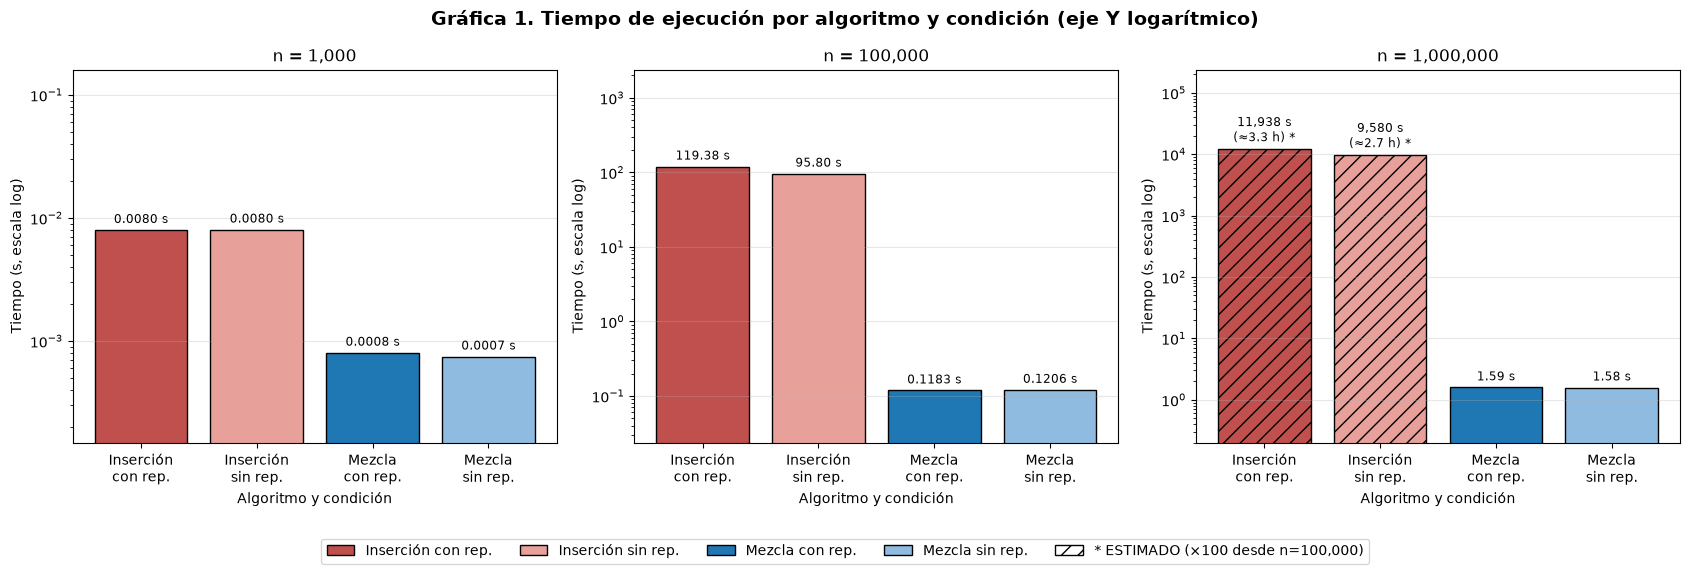

In [12]:
grafica_barras("tiempo", "Gráfica 1. Tiempo de ejecución por algoritmo y condición (eje Y logarítmico)",
               "Tiempo (s, escala log)", fmt_seg)

### Gráfica 2. Memoria máxima por escenario

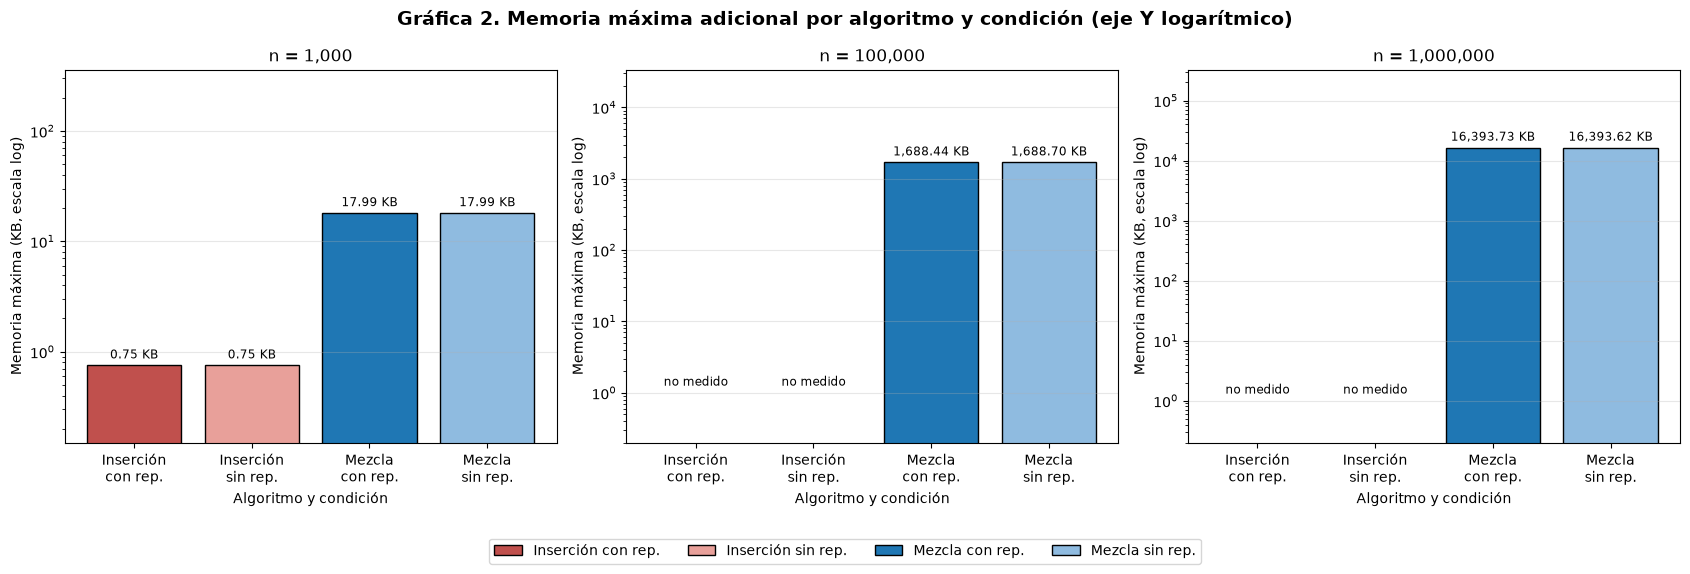

In [13]:
grafica_barras("memoria", "Gráfica 2. Memoria máxima adicional por algoritmo y condición (eje Y logarítmico)",
               "Memoria máxima (KB, escala log)", lambda v: f"{v:,.2f} KB")

### Gráfica 3. Escalabilidad (log-log)

En escala log-log una función $t = c\,n^k$ se ve como una **recta de pendiente $k$**: Inserción debe verse con pendiente ≈ 2 y Mezcla con pendiente ≈ 1 (ligeramente mayor por el factor $\log n$). Las líneas punteadas grises son las referencias teóricas $n^2$ y $n\log n$ ajustadas al primer punto. Los puntos **huecos** son **ESTIMADOS**.

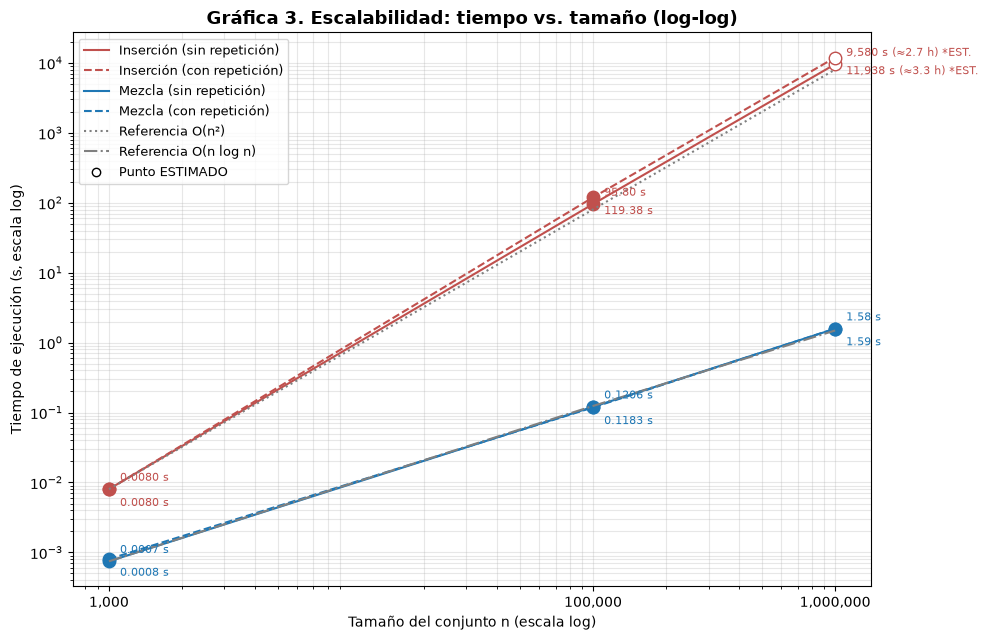

In [14]:
fig, ax = plt.subplots(figsize=(10, 6.5))
estilos = {"Inserción": "#c0504d", "Mezcla": "#1f77b4"}
lineas = {"Sin repetición": "-", "Con repetición": "--"}
for alg, color in estilos.items():
    for cond, ls in lineas.items():
        d = df[(df.Algoritmo == alg) & (df.cond == cond)].sort_values("n")
        ax.plot(d.n, d.tiempo, ls, color=color, label=f"{alg} ({cond.lower()})")
        for _, f in d.iterrows():
            ax.plot(f.n, f.tiempo, "o", markersize=9, color=color,
                    markerfacecolor="white" if f.estimado else color)
            ax.annotate(fmt_seg(f.tiempo).replace("\n", " ") + (" *EST." if f.estimado else ""),
                        (f.n, f.tiempo), xytext=(8, -12 if cond == "Con repetición" else 6),
                        textcoords="offset points", fontsize=8, color=color)

ns = np.array(TAMANIOS, dtype=float)
t0_ins = dato("Inserción", 1_000, "Sin repetición").tiempo
t0_mez = dato("Mezcla", 1_000, "Sin repetición").tiempo
ax.plot(ns, t0_ins * (ns / 1_000) ** 2, ":", color="gray", label="Referencia O(n²)")
ax.plot(ns, t0_mez * (ns * np.log2(ns)) / (1_000 * np.log2(1_000)), "-.", color="gray", label="Referencia O(n log n)")
ax.plot([], [], "o", color="black", markerfacecolor="white", label="Punto ESTIMADO")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xticks(TAMANIOS, [f"{n:,}" for n in TAMANIOS])
ax.set_xlabel("Tamaño del conjunto n (escala log)")
ax.set_ylabel("Tiempo de ejecución (s, escala log)")
ax.set_title("Gráfica 3. Escalabilidad: tiempo vs. tamaño (log-log)", fontsize=13, fontweight="bold")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## 10. Conclusión

> **Datos estimados / no medidos:** los tiempos de **Inserción con n = 1,000,000** son **ESTIMADOS** (tiempo medido con 100,000 × 100 → 9,580 s ≈ 2.7 h sin repetición y 11,938 s ≈ 3.3 h con repetición), no medidos. La **memoria de Inserción con n = 100,000 y 1,000,000 no se midió** (ver secciones 6 y 7.1). Todos los demás valores son mediciones reales de una sola corrida.

### n = 1,000

1. **Más rápido:** Mezcla (0.0007–0.0008 s) frente a Inserción (0.0080 s), unas **10 veces** más rápido. Aun con pocos datos, en este experimento Mezcla ganó.
2. **Más memoria:** Mezcla, con **17.99 KB** de pico adicional, contra **0.75 KB** de Inserción (~24 veces más).
3. **Repetidos:** sin efecto significativo; Inserción tardó 0.0080 s en ambos casos y Mezcla 0.0007 vs 0.0008 s. La memoria fue idéntica.
4. **Comportamiento:** es el punto de partida; con tan pocos datos los dos algoritmos terminan en milisegundos y la diferencia práctica es mínima.

### n = 100,000

1. **Más rápido:** Mezcla por mucho: **0.12 s** frente a **95.8 s** (sin rep.) y **119.4 s** (con rep.) de Inserción, es decir, entre **~800 y ~1,000 veces** más rápido.
2. **Más memoria:** Mezcla, con **1,688.7 KB (~1.6 MB)**. La de Inserción no se midió por la limitación de `tracemalloc`; por su diseño in-place se espera que siga siendo de unos pocos KB, como con n = 1,000.
3. **Repetidos:** en Mezcla no (0.1206 vs 0.1183 s, ~2 %). En Inserción la corrida con repetición fue **~25 % más lenta** (119.4 vs 95.8 s). La teoría no predice esa diferencia: con valores aleatorios, ambos conjuntos requieren prácticamente el mismo número de desplazamientos (≈ n²/4), y con `>` un elemento repetido incluso se detiene antes. Como cada valor es una sola corrida, lo más probable es que se deba a variación del equipo: frecuencia dinámica del procesador bajo carga sostenida, o que el proceso corriera parte del tiempo en un núcleo de eficiencia del i7-12700H (ver sección 1.1) y no a los repetidos; no se considera una diferencia concluyente.
4. **Comportamiento:** aquí la brecha se vuelve enorme: Inserción pasa de milisegundos a **minutos**, mientras Mezcla sigue en décimas de segundo.

### n = 1,000,000

1. **Más rápido:** Mezcla, con **1.58–1.59 s** medidos, contra un tiempo **estimado** de **2.7–3.3 horas** para Inserción (~6,000–7,500 veces más).
2. **Más memoria:** Mezcla, con **16,393 KB (~16 MB)** de pico adicional. La de Inserción **no se midió** (no se ejecutó); teóricamente sería O(1).
3. **Repetidos:** en Mezcla no (1.5792 vs 1.5851 s, <1 %; memoria prácticamente igual). En Inserción la diferencia entre las estimaciones solo arrastra la diferencia observada con 100,000.
4. **Comportamiento:** Inserción se vuelve **impráctico** (horas), mientras Mezcla ordena un millón de elementos en poco más de un segundo y medio.

### ¿Coinciden los resultados con la complejidad teórica?

**Sí.** Según la tabla de la sección 8.1:

| Algoritmo | Paso | Crecimiento observado | Teórico |
|---|---|---|---|
| Inserción $O(n^2)$ | 1,000 → 100,000 | ×11,929 (sin rep.) / ×14,972 (con rep.) | ×10,000 |
| Mezcla $O(n \log n)$ | 1,000 → 100,000 | ×161.8 / ×147.7 | ×166.7 |
| Mezcla $O(n \log n)$ | 100,000 → 1,000,000 | ×13.1 / ×13.4 | ×12.0 |

- **Tiempo:** al multiplicar n por 100, el tiempo de Inserción creció ~×10⁴ (**cuadrático**, $O(n^2)$), y el de Mezcla solo ~×150–160 (**casi lineal**, $O(n \log n)$). En la Gráfica 3 (log-log) Inserción sigue la recta de pendiente 2 y Mezcla la de $n \log n$. El crecimiento de Inserción es algo mayor que el teórico, probablemente porque con listas grandes los datos ya no caben en la memoria caché del procesador.
- **Memoria:** Mezcla usa memoria adicional **$O(n)$**: su pico creció ×93.9 de 1,000 a 100,000 y ×9.7 de 100,000 a 1,000,000, prácticamente proporcional a n (≈16 bytes por elemento). Inserción ordena **in-place** con memoria adicional **$O(1)$**: con n = 1,000 solo usó 0.75 KB, que corresponden a unas cuantas variables temporales y no a una copia de la lista.
- **Balance:** Mezcla cambia memoria por tiempo. Paga $O(n)$ memoria extra (16 MB con un millón de elementos) a cambio de ser miles de veces más rápido en conjuntos grandes. Inserción solo tiene sentido con listas pequeñas o casi ordenadas, donde su costo bajo en memoria y su simplicidad compensan.